# Ridge & Lasso Regularization: Vehicle CO₂ Emissions
## Regularización Ridge y Lasso: Emisiones de CO₂ por Vehículo

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `FuelConsumptionCo2.xlsx` — vehicle fuel consumption and CO₂ emissions

**Objective / Objetivo:**  
EN · Apply and compare OLS, Ridge, and Lasso regression to predict vehicle CO₂ emissions. Find the optimal alpha for each regularized model via cross-validation, validate that sklearn's `predict()` matches manual matrix calculation (β = (XᵀX)⁻¹Xᵀy), and forecast the first test observation.

ES · Aplicar y comparar regresión OLS, Ridge y Lasso para predecir emisiones de CO₂ de vehículos. Encontrar el alpha óptimo por validación cruzada, validar que `predict()` de sklearn coincide con el cálculo matricial manual, y pronosticar la primera observación del conjunto de prueba.

**Key finding / Hallazgo clave:** OLS, Ridge and Lasso predictions for the first test observation are nearly identical; confirming the equivalence between `predict()` and the manual matrix formula.

**Techniques / Técnicas:** OLS · Ridge · Lasso · Alpha tuning via CV · Manual matrix prediction · Train/Test split  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib` · `seaborn`

---

In [3]:
import pandas as pd
df = pd.read_excel('data/FuelConsumptionCo2.xlsx')

# Preparación de Datos

In [133]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [134]:
# ============================================================
# CARGA Y EXPLORACIÓN INICIAL DE DATOS
# ============================================================

df = pd.read_excel('data/FuelConsumptionCo2.xlsx')

print('⎯'*65)
print("INFORMACIÓN GENERAL DEL DATASET")
print('⎯'*65)
print(f"\n⋆ Dimensiones originales: {df.shape}\n")
print(df.info())
print("\n⋆ Muestra de 5 filas aleatorias:")
print(df.sample(5))

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
INFORMACIÓN GENERAL DEL DATASET
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯

⋆ Dimensiones originales: (945, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 945 non-null    int64  
 1   MAKE                      945 non-null    object 
 2   MODEL                     945 non-null    object 
 3   VEHICLECLASS              945 non-null    object 
 4   ENGINESIZE                945 non-null    float64
 5   CYLINDERS                 945 non-null    int64  
 6   TRANSMISSION              945 non-null    object 
 7   FUELTYPE                  945 non-null    object 
 8   FUELCONSUMPTION_CITY      945 non-null    float64
 9   FUELCONSUMPTION_HWY       945 non-null    float64
 10  FUELCONSUMPTION_COMB      94

In [89]:
# ============================================================
# ELIMINAR COLUMNAS CATEGÓRICAS Y VERIFICAR NULOS
# ============================================================

print('\n' + '⎯'*65)
print("ELIMINACIÓN DE COLUMNAS CATEGÓRICAS")
print('⎯'*65)

# Identificar columnas categóricas (tipo object)
cols_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n⋆ Columnas categóricas a eliminar: {cols_categoricas}")

# Eliminar columnas categóricas
df_num = df.drop(columns=cols_categoricas)
print(f"\n⋆ Columnas remanentes (numéricas):")
print(df_num.columns.tolist())
print(f"\n⋆ Dimensiones después de eliminar categóricas: {df_num.shape}")

# Verificar valores nulos
print('\n' + '⎯'*65)
print("VERIFICACIÓN DE VALORES NULOS")
print('⎯'*65)
print(df_num.isnull().sum())
print(f"\n⋆ Total de valores nulos: {df_num.isnull().sum().sum()}")

if df_num.isnull().sum().sum() == 0:
    print("  ✓ No existen valores nulos. No es necesario eliminar registros.")
else:
    df_num = df_num.dropna()
    print(f"  ✗ Se eliminaron filas con nulos. Nuevas dimensiones: {df_num.shape}")

# Estadísticas descriptivas
print('\n' + '⎯'*65)
print("ESTADÍSTICAS DESCRIPTIVAS")
print('⎯'*65)
print(df_num.describe().round(2))


⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
ELIMINACIÓN DE COLUMNAS CATEGÓRICAS
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯

⋆ Columnas categóricas a eliminar: ['MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']

⋆ Columnas remanentes (numéricas):
['MODELYEAR', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']

⋆ Dimensiones después de eliminar categóricas: (945, 8)

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
VERIFICACIÓN DE VALORES NULOS
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
MODELYEAR                   0
ENGINESIZE                  0
CYLINDERS                   0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

⋆ Total de valores nulos: 0
  ✓ No existen valores nulos. No es nec

# Visualización Exploratoria

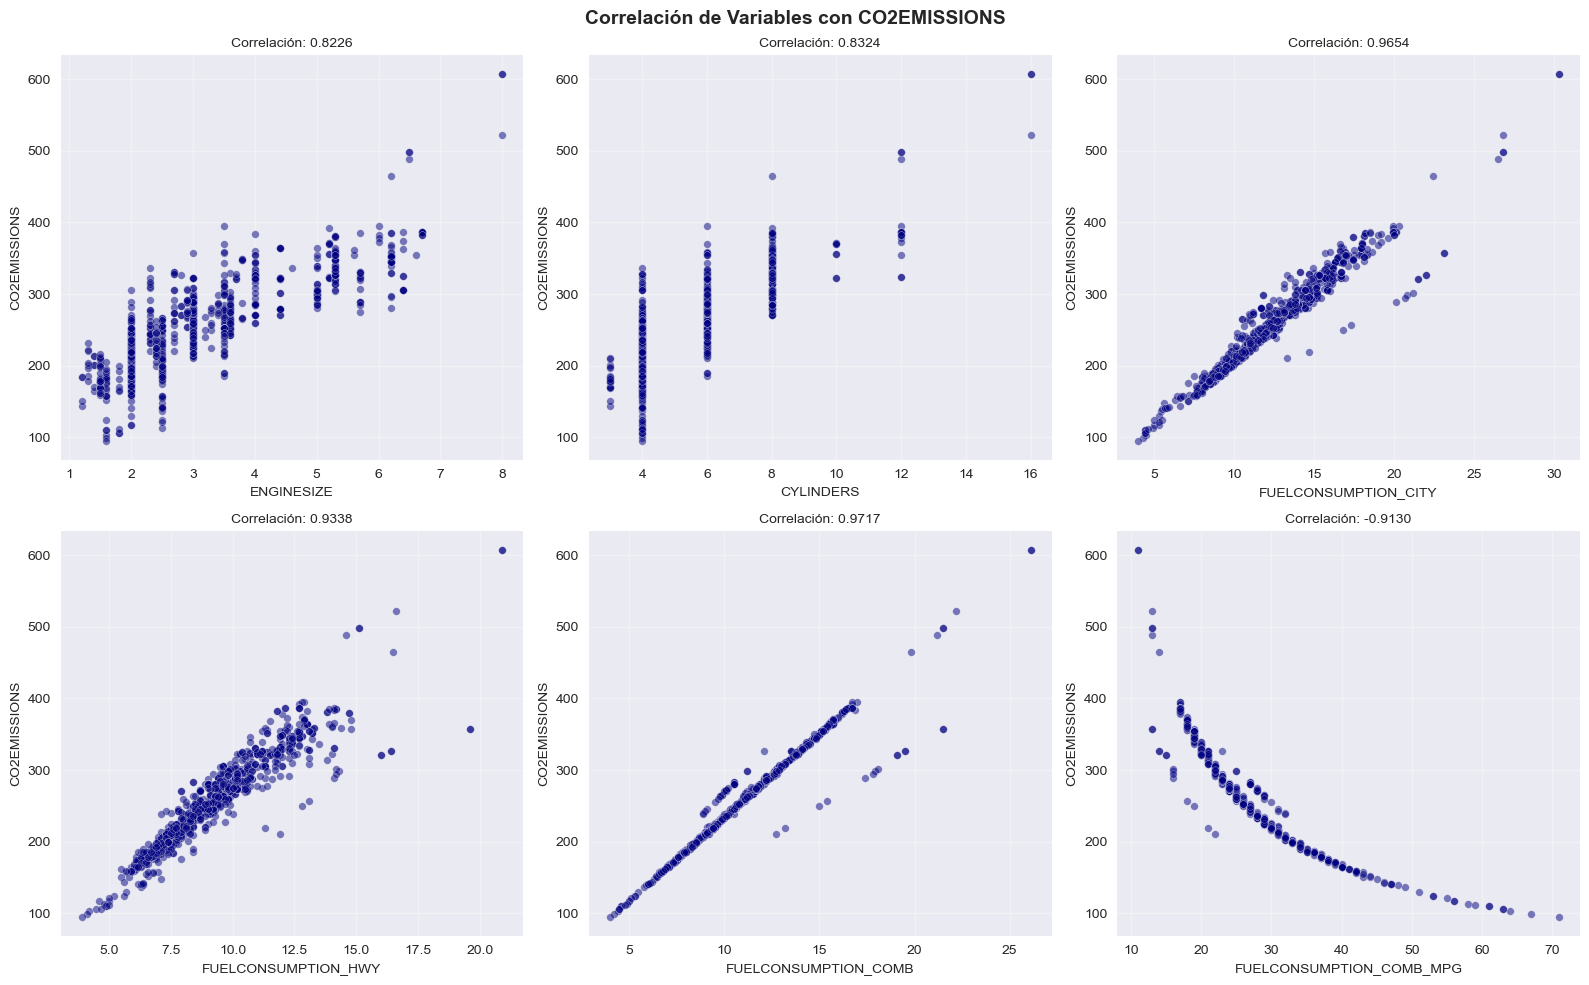

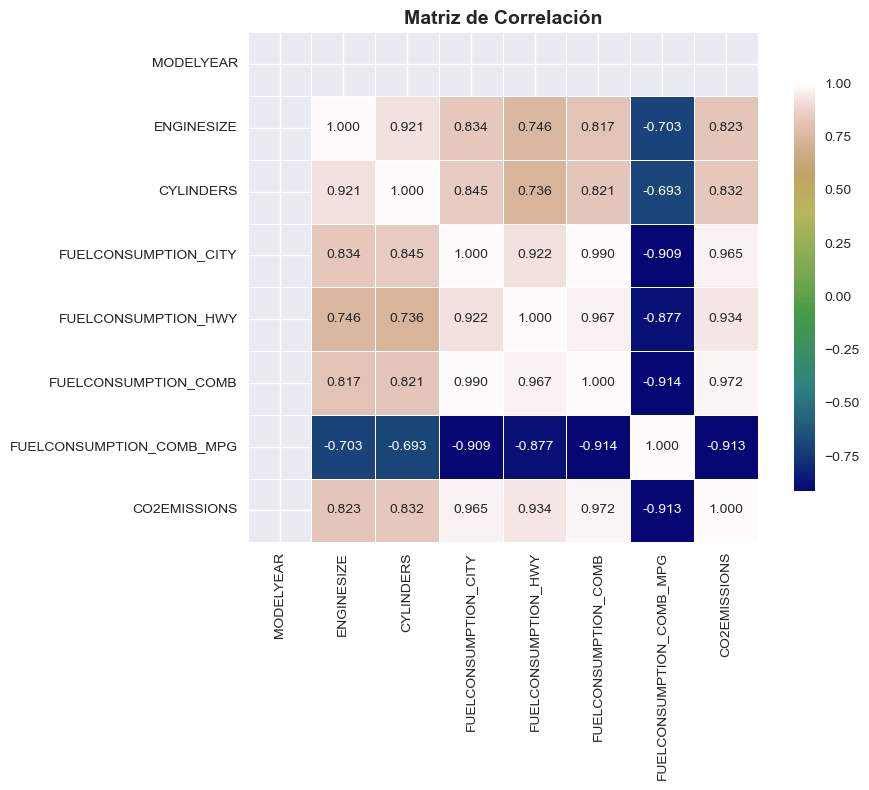


Correlaciones con CO2EMISSIONS:
CO2EMISSIONS                1.000000
FUELCONSUMPTION_COMB        0.971677
FUELCONSUMPTION_CITY        0.965437
FUELCONSUMPTION_HWY         0.933750
CYLINDERS                   0.832352
ENGINESIZE                  0.822554
FUELCONSUMPTION_COMB_MPG   -0.912990
MODELYEAR                        NaN
Name: CO2EMISSIONS, dtype: float64


In [130]:
# ============================================================
# ANÁLISIS EXPLORATORIO
# ============================================================

plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Correlación de Variables con CO2EMISSIONS', 
             fontsize=14, fontweight='bold')

features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 
            'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 
            'FUELCONSUMPTION_COMB_MPG']

for i, feature in enumerate(features):
    row, col = divmod(i, 3)
    axes[row, col].scatter(df_num[feature], df_num['CO2EMISSIONS'], 
                           alpha=0.5, color='navy', edgecolors='white', s=30)
    axes[row, col].set_xlabel(feature, fontsize=10)
    axes[row, col].set_ylabel('CO2EMISSIONS', fontsize=10)
    corr = df_num[feature].corr(df_num['CO2EMISSIONS'])
    axes[row, col].set_title(f'Correlación: {corr:.4f}', fontsize=10)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CO2_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Mapa de correlación
plt.figure(figsize=(10, 8))
corr_matrix = df_num.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='gist_earth',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('CO2_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelaciones con CO2EMISSIONS:")
print(corr_matrix['CO2EMISSIONS'].sort_values(ascending=False))

# División del Dataset y Escalado

In [131]:
# ============================================================
# PREPARACIÓN: VARIABLES X, Y, SPLIT Y ESCALADO
# ============================================================

# Variable objetivo y predictoras
X = df_num.drop(columns=['CO2EMISSIONS'])
y = df_num['CO2EMISSIONS']

print(f"⋆ Variables predictoras (X): {X.columns.tolist()}")
print(f"⋆ Variable objetivo (y): CO2EMISSIONS")
print(f"\n⋆ Dimensiones X: {X.shape}")
print(f"⋆ Dimensiones y: {y.shape}")

# División entrenamiento/prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n⋆ Tamaño conjunto entrenamiento: {X_train.shape}")
print(f"⋆ Tamaño conjunto prueba: {X_test.shape}")

# Escalado de características (Estandarización: Media ≈ 0, Desviación estándar ≈ 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertir a DataFrame para mejor manejo
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

⋆ Variables predictoras (X): ['MODELYEAR', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']
⋆ Variable objetivo (y): CO2EMISSIONS

⋆ Dimensiones X: (945, 7)
⋆ Dimensiones y: (945,)

⋆ Tamaño conjunto entrenamiento: (756, 7)
⋆ Tamaño conjunto prueba: (189, 7)


# Regresión Lineal Múltiple (OLS)
Penalización: Ninguna

Coef. sin restricción

Min: Σ(y - ŷ)²

In [132]:
# ============================================================
# MODELO 1: REGRESIÓN LINEAL MÚLTIPLE (OLS)
# ============================================================

print('='*65)
print("MODELO 1: REGRESIÓN LINEAL MÚLTIPLE (OLS)")
print('='*65)

# Entrenar modelo
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test  = lr_model.predict(X_test_scaled)

# ---- Métricas ----
def calcular_metricas(y_real, y_pred, nombre_modelo, conjunto):
    r2   = r2_score(y_real, y_pred)
    mae  = mean_absolute_error(y_real, y_pred)
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    
    print(f"\n  [{nombre_modelo}] - Conjunto {conjunto}:")
    print(f"    R²   (R-cuadrada)        : {r2:.6f}")
    print(f"    MAE  (Error Medio Abs.)  : {mae:.4f}")
    print(f"    MSE  (Error Cuadrático)  : {mse:.4f}")
    print(f"    RMSE (Raíz Error Cuad.)  : {rmse:.4f}")
    print(f"    MAPE (Error % Promedio)  : {mape:.4f}%")
    
    return {'R2': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

metricas_lr_train = calcular_metricas(y_train, y_pred_lr_train, "OLS", "ENTRENAMIENTO")
metricas_lr_test  = calcular_metricas(y_test,  y_pred_lr_test,  "OLS", "PRUEBA")

# ---- Coeficientes ----
print('\n' + '⎯'*60)
print("COEFICIENTES DEL MODELO OLS:")
print('⎯'*60)
print(f"  ⋆ Intercepto (β₀): {lr_model.intercept_:.6f}")
print("\n  ⋆ Coeficientes (βᵢ):")
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print(coef_df.to_string(index=False))

MODELO 1: REGRESIÓN LINEAL MÚLTIPLE (OLS)

  [OLS] - Conjunto ENTRENAMIENTO:
    R²   (R-cuadrada)        : 0.964489
    MAE  (Error Medio Abs.)  : 5.5158
    MSE  (Error Cuadrático)  : 151.3705
    RMSE (Raíz Error Cuad.)  : 12.3033
    MAPE (Error % Promedio)  : 2.1077%

  [OLS] - Conjunto PRUEBA:
    R²   (R-cuadrada)        : 0.900492
    MAE  (Error Medio Abs.)  : 7.3391
    MSE  (Error Cuadrático)  : 368.8673
    RMSE (Raíz Error Cuad.)  : 19.2059
    MAPE (Error % Promedio)  : 2.6272%

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
COEFICIENTES DEL MODELO OLS:
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
  ⋆ Intercepto (β₀): 260.215608

  ⋆ Coeficientes (βᵢ):
                Variable  Coeficiente
    FUELCONSUMPTION_COMB    36.270859
FUELCONSUMPTION_COMB_MPG    -9.767923
     FUELCONSUMPTION_HWY     7.958612
               CYLINDERS     7.956320
    FUELCONSUMPTION_CITY     4.189648
              ENGINESIZE     0.317134
               MODELYEAR     

In [128]:
# ============================================================
# PRONÓSTICO MANUAL VS PREDICT - PRIMERA OBSERVACIÓN DE PRUEBA
# ============================================================

print('\n' + '='*65) 
print("VERIFICACIÓN: PRONÓSTICO MANUAL vs PREDICT")
print('='*65)

# Primera observación del conjunto de prueba
primera_obs_scaled = X_test_scaled[0].reshape(1, -1)
primera_obs_original = X_test.iloc[0]

print("\n⋆ Valores originales de la primera observación de prueba:")
print(primera_obs_original.to_string())
print(f"\n⋆ Valor REAL de CO2EMISSIONS: {y_test.iloc[0]}")

# ---- Método 1: Usando predict ----
pred_predict = lr_model.predict(primera_obs_scaled)[0]
print(f"\n   Método 1: predict()      ➝ {pred_predict:.6f}")

# ---- Método 2: Cálculo manual (β₀ + β₁X₁ + ... + βₙXₙ) ----
coeficientes = lr_model.coef_
intercepto   = lr_model.intercept_
valores_escalados = X_test_scaled[0]

pred_manual = intercepto + np.dot(coeficientes, valores_escalados)
print(f"   Método 2: Cálculo manual ➝ {pred_manual:.6f}")

# Verificación
diferencia = abs(pred_predict - pred_manual)
print(f"\n   Diferencia absoluta (Método 1 - Método 2) ➝ {diferencia:.10f}")
print(f"\n   ¿Coinciden? {'SÍ' if diferencia < 1e-6 else 'NO'}")
print("""
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
EXPLICACIÓN
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
Ambos resultados son idénticos porque 'predict()' internamente realiza exactamente la misma operación: 
  
       ŷ = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ
  
La instrucción predict() es simplemente una implementación vectorizada y optimizada de esta fórmula matricial:
  
       ŷ = X · β + β₀
  
No existe diferencia conceptual entre ambos métodos; cualquier pequeña discrepancia (< 1e-10) 
sería únicamente por precisión de punto flotante.
""")


VERIFICACIÓN: PRONÓSTICO MANUAL vs PREDICT

⋆ Valores originales de la primera observación de prueba:
MODELYEAR                   2022.0
ENGINESIZE                     2.4
CYLINDERS                      4.0
FUELCONSUMPTION_CITY          12.0
FUELCONSUMPTION_HWY            8.8
FUELCONSUMPTION_COMB          10.5
FUELCONSUMPTION_COMB_MPG      27.0

⋆ Valor REAL de CO2EMISSIONS: 247

   Método 1: predict()      ➝ 242.926940
   Método 2: Cálculo manual ➝ 242.926940

   Diferencia absoluta (Método 1 - Método 2) ➝ 0.0000000000

   ¿Coinciden? SÍ

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
EXPLICACIÓN
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
Ambos resultados son idénticos porque 'predict()' internamente realiza exactamente la misma operación: 

       ŷ = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ

La instrucción predict() es simplemente una implementación vectorizada y optimizada de esta fórmula matricial:

       ŷ = X · β + β₀

No existe diferencia conceptual entre ambos métodos; cualquier pequeña discrepancia (< 1e-10) 
sería únicamente por preci

# Regresión Ridge (L2) con Alpha Óptimo
Penalización: λ·Σβᵢ² 

Coef. → 0 (jamás = 0)

MODELO 2: REGRESIÓN RIDGE

  ⋆ Alpha óptimo (RidgeCV, 10-fold): 13.049020



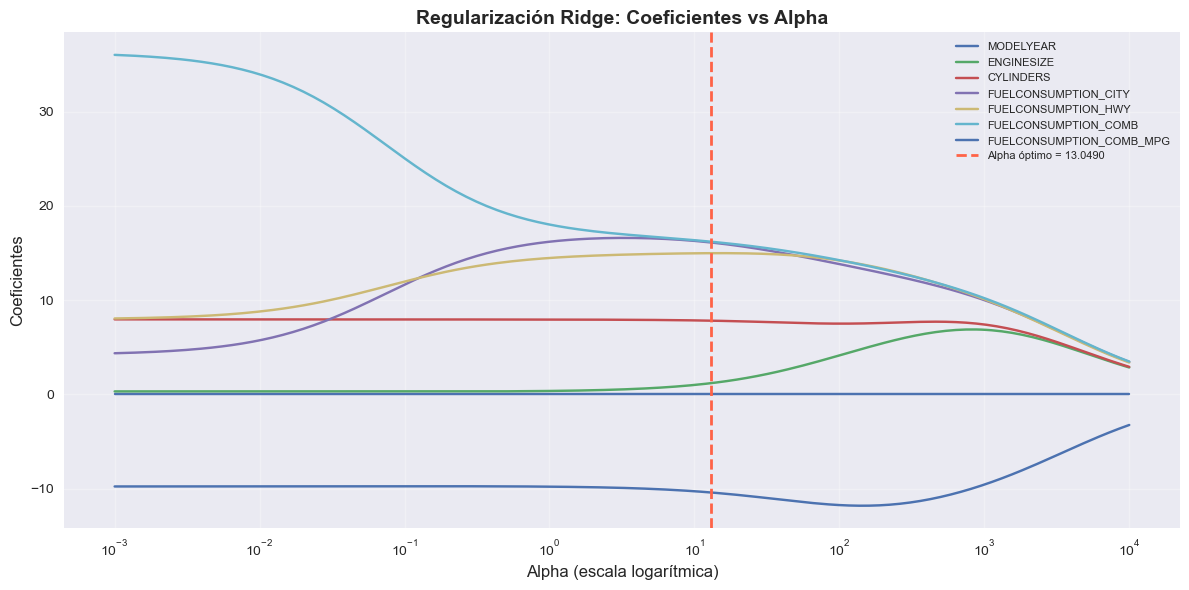


  [Ridge] - Conjunto ENTRENAMIENTO:
    R²   (R-cuadrada)        : 0.964402
    MAE  (Error Medio Abs.)  : 5.7126
    MSE  (Error Cuadrático)  : 151.7391
    RMSE (Raíz Error Cuad.)  : 12.3182
    MAPE (Error % Promedio)  : 2.1881%

  [Ridge] - Conjunto PRUEBA:
    R²   (R-cuadrada)        : 0.902893
    MAE  (Error Medio Abs.)  : 7.4749
    MSE  (Error Cuadrático)  : 359.9673
    RMSE (Raíz Error Cuad.)  : 18.9728
    MAPE (Error % Promedio)  : 2.6875%

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
COEFICIENTES DEL MODELO RIDGE (Alpha = 13.0490):
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
  ⋆ Intercepto (β₀): 260.215608


  ⋆ Coeficientes (βᵢ):
                Variable  Coef. Ridge  Coef. OLS
    FUELCONSUMPTION_COMB    16.193071  36.270859
    FUELCONSUMPTION_CITY    16.109678   4.189648
     FUELCONSUMPTION_HWY    14.977036   7.958612
FUELCONSUMPTION_COMB_MPG   -10.407812  -9.767923
               CYLINDERS     7.818163   7.956320
              ENGINESIZE     1.191936 

In [113]:
# ============================================================
# MODELO 2: REGRESIÓN RIDGE (con Alpha óptimo via RidgeCV)
# ============================================================

print('='*65)
print("MODELO 2: REGRESIÓN RIDGE")
print('='*65)

# ---- Búsqueda del Alpha óptimo ----
alphas_ridge = np.logspace(-3, 4, 200)  # de 0.001 a 10000

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

alpha_optimo_ridge = ridge_cv.alpha_
print(f"\n  ⋆ Alpha óptimo (RidgeCV, 10-fold): {alpha_optimo_ridge:.6f}\n")

# Visualizar el efecto del alpha en los coeficientes
coefs_ridge = []
for alpha in alphas_ridge:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train_scaled, y_train)
    coefs_ridge.append(ridge_temp.coef_)

plt.figure(figsize=(12, 6))
plt.semilogx(alphas_ridge, coefs_ridge)
plt.axvline(x=alpha_optimo_ridge, color='tomato', linestyle='--', 
            linewidth=2, label=f'Alpha óptimo = {alpha_optimo_ridge:.4f}')
plt.xlabel('Alpha (escala logarítmica)', fontsize=12)
plt.ylabel('Coeficientes', fontsize=12)
plt.title('Regularización Ridge: Coeficientes vs Alpha', fontsize=14, fontweight='bold')
plt.legend(X.columns.tolist() + [f'Alpha óptimo = {alpha_optimo_ridge:.4f}'], 
           loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('CO2_ridge_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Entrenar modelo Ridge con alpha óptimo ----
ridge_model = Ridge(alpha=alpha_optimo_ridge)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge_model.predict(X_train_scaled)
y_pred_ridge_test  = ridge_model.predict(X_test_scaled)

# Métricas
metricas_ridge_train = calcular_metricas(y_train, y_pred_ridge_train, "Ridge", "ENTRENAMIENTO")
metricas_ridge_test  = calcular_metricas(y_test,  y_pred_ridge_test,  "Ridge", "PRUEBA")

# Coeficientes
print('\n' + '⎯'*50)
print(f"COEFICIENTES DEL MODELO RIDGE (Alpha = {alpha_optimo_ridge:.4f}):")
print('⎯'*50)
print(f"  ⋆ Intercepto (β₀): {ridge_model.intercept_:.6f}\n")
print("\n  ⋆ Coeficientes (βᵢ):")
coef_ridge_df = pd.DataFrame({
    'Variable': X.columns,
    'Coef. Ridge': ridge_model.coef_,
    'Coef. OLS':   lr_model.coef_
}).sort_values('Coef. Ridge', key=abs, ascending=False)
print(coef_ridge_df.to_string(index=False))

# ---- Pronóstico manual primera obs. prueba ----
pred_ridge_predict = ridge_model.predict(primera_obs_scaled)[0]
pred_ridge_manual  = ridge_model.intercept_ + np.dot(ridge_model.coef_, valores_escalados)

print('\n' + '⎯'*50)
print(f"PRONÓSTICO RIDGE:")
print('⎯'*50)
print(f"   predict():  {pred_ridge_predict:.6f}")
print(f"   Manual:     {pred_ridge_manual:.6f}")
print(f"   Valor real: {y_test.iloc[0]}")

# Regresión Lasso (L1) con Alpha Óptimo
Penalización: λ·Σ|βᵢ|

Coef. = 0 posible

# Comparación Final de Modelos


TABLA COMPARATIVA DE MÉTRICAS - CONJUNTO DE PRUEBA
 Métrica        OLS      Ridge      Lasso
      R²   0.900492   0.902893   0.900512
     MAE   7.339145   7.474899   7.341384
     MSE 368.867260 359.967329 368.792970
    RMSE  19.205917  18.972805  19.203983
MAPE (%)   2.627152   2.687526   2.629279



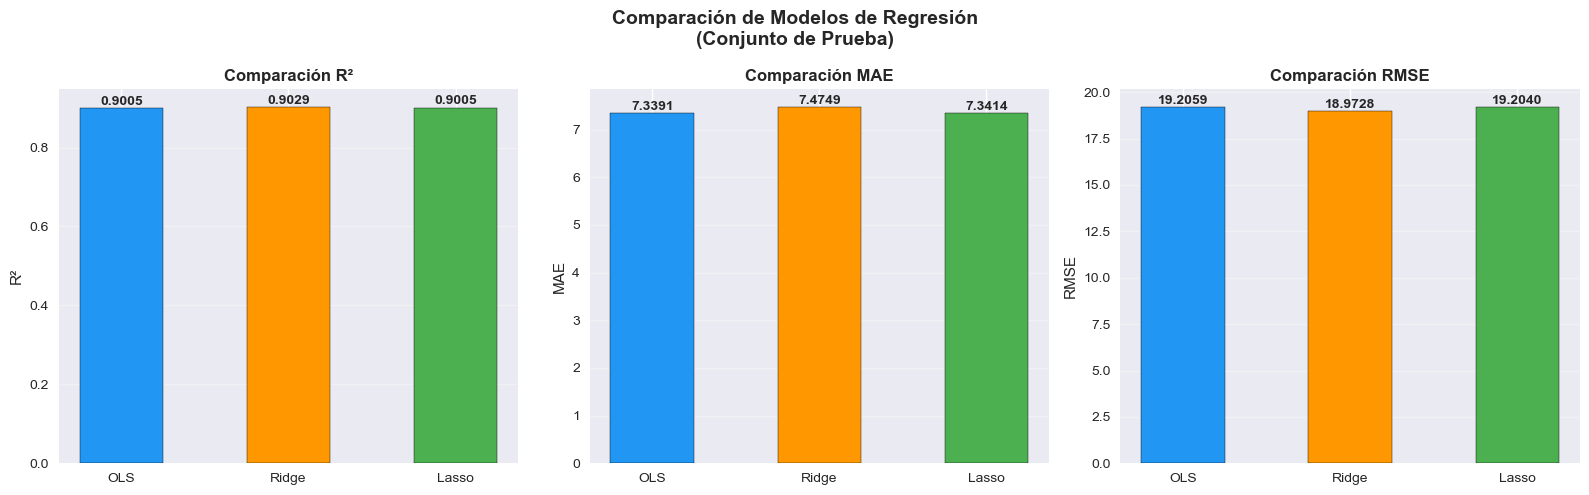

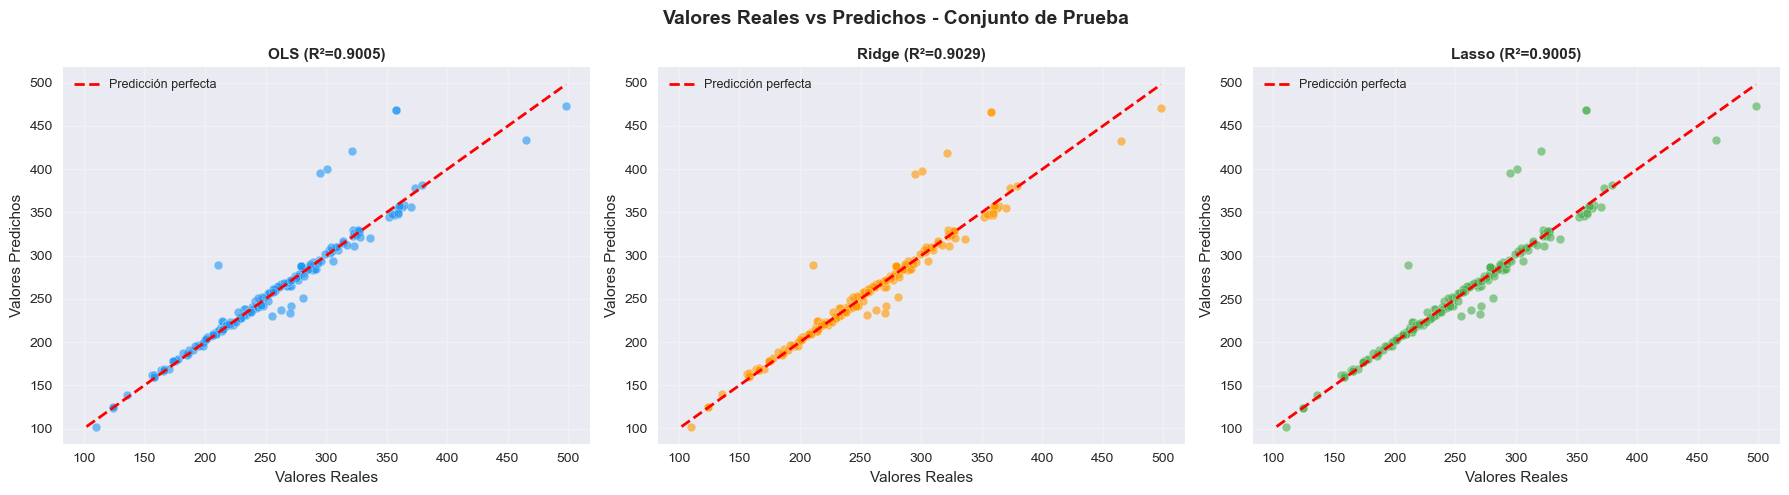

In [135]:
# ============================================================
# COMPARACIÓN FINAL DE LOS 3 MODELOS
# ============================================================
print('\n' + '='*65)
print('TABLA COMPARATIVA DE MÉTRICAS - CONJUNTO DE PRUEBA')
print('='*65)

resultados = pd.DataFrame({
    'Métrica':     ['R²', 'MAE', 'MSE', 'RMSE', 'MAPE (%)'],
    'OLS':  [
        metricas_lr_test['R2'],
        metricas_lr_test['MAE'],
        metricas_lr_test['MSE'],
        metricas_lr_test['RMSE'],
        metricas_lr_test['MAPE']
    ],
    'Ridge': [
        metricas_ridge_test['R2'],
        metricas_ridge_test['MAE'],
        metricas_ridge_test['MSE'],
        metricas_ridge_test['RMSE'],
        metricas_ridge_test['MAPE']
    ],
    'Lasso': [
        metricas_lasso_test['R2'],
        metricas_lasso_test['MAE'],
        metricas_lasso_test['MSE'],
        metricas_lasso_test['RMSE'],
        metricas_lasso_test['MAPE']
    ]
})

print(resultados.to_string(index=False) + '\n')

# ---- Gráfico comparativo de métricas ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación de Modelos de Regresión\n(Conjunto de Prueba)', 
             fontsize=14, fontweight='bold')

modelos  = ['OLS', 'Ridge', 'Lasso']
colores  = ['#2196F3', '#FF9800', '#4CAF50']
metricas_nombres = ['R²', 'MAE', 'RMSE']
valores_list = [
    [metricas_lr_test['R2'],   metricas_ridge_test['R2'],   metricas_lasso_test['R2']],
    [metricas_lr_test['MAE'],  metricas_ridge_test['MAE'],  metricas_lasso_test['MAE']],
    [metricas_lr_test['RMSE'], metricas_ridge_test['RMSE'], metricas_lasso_test['RMSE']]
]

for i, (metrica, valores) in enumerate(zip(metricas_nombres, valores_list)):
    bars = axes[i].bar(modelos, valores, color=colores, edgecolor='black', width=0.5)
    axes[i].set_title(f'Comparación {metrica}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metrica, fontsize=11)
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('CO2_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Gráfico de valores reales vs predichos ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Valores Reales vs Predichos - Conjunto de Prueba', 
             fontsize=14, fontweight='bold')

predicciones = [y_pred_lr_test, y_pred_ridge_test, y_pred_lasso_test]
titulos      = [f'OLS (R²={metricas_lr_test["R2"]:.4f})', 
                f'Ridge (R²={metricas_ridge_test["R2"]:.4f})',
                f'Lasso (R²={metricas_lasso_test["R2"]:.4f})']

for i, (pred, titulo, color) in enumerate(zip(predicciones, titulos, colores)):
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    axes[i].scatter(y_test, pred, alpha=0.6, color=color, edgecolors='white', s=40)
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
    axes[i].set_xlabel('Valores Reales', fontsize=11)
    axes[i].set_ylabel('Valores Predichos', fontsize=11)
    axes[i].set_title(titulo, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CO2_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen final de pronósticos

In [123]:
# ============================================================
# RESUMEN FINAL DE PRONÓSTICOS
# ============================================================

print('\n' + '⎯'*50)
print("ALPHAS ÓPTIMOS UTILIZADOS")
print('⎯'*50)
print(f"  Ridge - Alpha óptimo: {alpha_optimo_ridge:.6f}")
print(f"  Lasso - Alpha óptimo: {alpha_optimo_lasso:.6f}")

print('\n' + '⎯'*50)
print("PRONÓSTICOS - PRIMERA OBSERVACIÓN DE PRUEBA")
print('⎯'*50)
print(f"  Valor real CO2EMISSIONS ➝ {y_test.iloc[0]}")
print(f"  OLS   - predict()       ➝ {pred_predict:.4f}")
print(f"  Ridge - predict()       ➝ {pred_ridge_predict:.4f}")
print(f"  Lasso - predict()       ➝ {pred_lasso_predict:.4f}")


⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
ALPHAS ÓPTIMOS UTILIZADOS
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
  Ridge - Alpha óptimo: 13.049020
  Lasso - Alpha óptimo: 0.045006

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
PRONÓSTICOS - PRIMERA OBSERVACIÓN DE PRUEBA
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
  Valor real CO2EMISSIONS ➝ 247
  OLS   - predict()       ➝ 242.9269
  Ridge - predict()       ➝ 243.1974
  Lasso - predict()       ➝ 243.1526


# Conclusiones

In [129]:
print("""
===============================================================
CONCLUSIONES DEL ANÁLISIS COMPARATIVO
===============================================================

   PRONÓSTICO MANUAL vs PREDICT
   ───────────────────────────────────────────────────────────── 
   Los resultados son IDÉNTICOS porque predict() implementa
   exactamente:  ŷ = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ
   La diferencia < 1e-10 es solo precisión de punto flotante.

   ¿CUÁL ES EL MEJOR MODELO?
   ───────────────────────────────────────────────────────────── 
  🥇 RIDGE  →  Mejor modelo general
      • Mayor R² en prueba: 0.9029
      • Menor MSE en prueba: 359.97
      • Menor RMSE en prueba: 18.9728
      • Estabiliza coeficientes ante multicolinealidad severa
        (r > 0.97 entre variables de consumo)
      • α óptimo = 13.049020

  🥈 LASSO 
      • Único modelo que realizó selección de variables, eliminando automáticamente MODELYEAR
        (varianza = 0, sin poder predictivo).
      • Métricas similares a OLS pero con modelo más parsimonioso (6 variables en lugar de 7).
      • MAE: 7.3414 | RMSE: 19.2040 | R²: 0.9005
      • α óptimo = 0.045006

  🥉 OLS
      • No regulariza coeficientes inflados por multicolinealidad
      • Incluye MODELYEAR (coef=0) sin detectarlo como variable irrelevante de forma explícita
      • MAE: 7.3391 | RMSE: 19.2059 | R²: 0.9005
""")


CONCLUSIONES DEL ANÁLISIS COMPARATIVO

   PRONÓSTICO MANUAL vs PREDICT
   ───────────────────────────────────────────────────────────── 
   Los resultados son IDÉNTICOS porque predict() implementa
   exactamente:  ŷ = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ
   La diferencia < 1e-10 es solo precisión de punto flotante.

   ¿CUÁL ES EL MEJOR MODELO?
   ───────────────────────────────────────────────────────────── 
  🥇 RIDGE  →  Mejor modelo general
      • Mayor R² en prueba: 0.9029
      • Menor MSE en prueba: 359.97
      • Menor RMSE en prueba: 18.9728
      • Estabiliza coeficientes ante multicolinealidad severa
        (r > 0.97 entre variables de consumo)
      • α óptimo = 13.049020

  🥈 LASSO 
      • Único modelo que realizó selección de variables, eliminando automáticamente MODELYEAR
        (varianza = 0, sin poder predictivo).
      • Métricas similares a OLS pero con modelo más parsimonioso (6 variables en lugar de 7).
      • MAE: 7.3414 | RMSE: 19.2040 | R²: 0.9005
      • α óptimo